In [1]:
%%capture
import os
import nest_asyncio
from IPython.display import Markdown, HTML, display
from dotenv import load_dotenv
from notebooks import experiment_utils
from app.core.container import Container
from app.interface.api.messages.schema import MessageRequest

os.chdir("..")
load_dotenv()
nest_asyncio.apply()

# start dependency injection container
container = Container()
container.init_resources()
container.wire(modules=[__name__])

# get checkpointer instance
graph_persistence_factory = container.graph_persistence_factory()
checkpointer = graph_persistence_factory.build_checkpoint_saver()

In [2]:
# Create Workflow
xai_agent = experiment_utils.create_xai_agent(
    agent_type="quaks_financial_analyst_v1", llm_tag="grok-4-1-fast-non-reasoning", api_key=os.getenv("XAI_API_KEY")
)
xai_financial_analyst = container.quaks_financial_analyst_v1_agent()
xai_workflow_builder = xai_financial_analyst.get_workflow_builder(xai_agent["id"])
xai_workflow = xai_workflow_builder.compile(checkpointer=checkpointer)

In [3]:
message = MessageRequest(
    message_role="human",
    message_content="BATCH_ETL META, GOOGL",
    agent_id=xai_agent["id"],
)

inputs = xai_financial_analyst.get_input_params(message, schema="public")
config = xai_financial_analyst.get_config(xai_agent["id"])
result = xai_workflow.invoke(inputs, config)
ai_message_content, workflow_state = xai_financial_analyst.format_response(result)

In [4]:
display(HTML(ai_message_content))

In [5]:
%%capture

message = MessageRequest(
    message_role="human",
    message_content="Can you share the most important take of GOOGL?",
    agent_id=xai_agent["id"],
)

inputs = xai_financial_analyst.get_input_params(message, schema="public")
config = xai_financial_analyst.get_config(xai_agent["id"])
result = xai_workflow.invoke(inputs, config)
ai_message_content, workflow_state = xai_financial_analyst.format_response(result)

In [6]:
display(Markdown(ai_message_content))

**GOOGL Key Takeaway:** Strong fundamentals (22x P/E discount to peers, 28% ROE, diversified growth) make it undervalued long-term, but HOLD short-term due to neutral technicals (price between EMAs, weak ADX 18.2, RSI 55)—wait for breakout above 50-day EMA (~$182) before buying.

Always do your own research before investing.

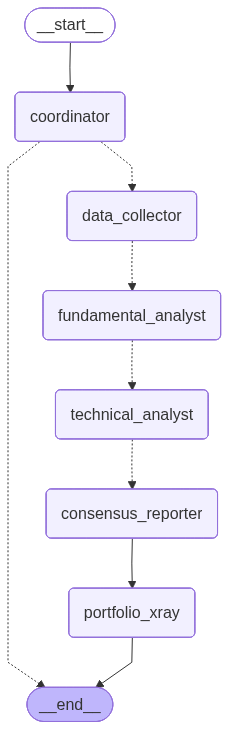

In [7]:
experiment_utils.print_graph(xai_workflow)

In [8]:
print(f"### Coordinator system prompt\n\n{result['coordinator_system_prompt']}\n")

### Coordinator system prompt

You are the Quaks Financial Analyst — a knowledgeable investment analysis assistant.
Current time: Tue Mar 17 2026 13:03:25 

## Role
Answer the user's question directly and concisely. You are an expert in investments, financial markets, stocks, fundamental analysis, technical analysis, and risk assessment.

## Scope — STRICT
You ONLY answer questions related to:
- Stock analysis, valuation, fundamental and technical analysis
- Financial markets, exchanges, market trends, economic indicators
- Company fundamentals, earnings, valuations, financial statements
- Portfolio strategy, asset allocation, risk management
- Macroeconomics, monetary policy, interest rates, inflation

For ANY question outside this scope, respond with:
"I'm the Quaks Financial Analyst and I can only help with investment and financial analysis topics. Please ask me something related to stock analysis, markets, or finance."

## Guidelines
- Be concise and factual. Do not speculate.
- Us

In [9]:
print(f"### Data Collector system prompt\n\n{result['data_collector_system_prompt']}\n")

### Data Collector system prompt

You are a Financial Data Collector for an investment analysis service.
Current time: Tue Mar 17 2026 13:03:25 

## Execution Plan
Financial analysis plan:
1. coordinator: Parse ticker(s) and decide whether to proceed
2. data_collector: Fetch company profile, price stats, technical indicators, and news for each ticker
3. fundamental_analyst: Evaluate valuation, profitability, and financial health → BUY/HOLD/SELL
4. technical_analyst: Evaluate price action, momentum, and trend signals → BUY/HOLD/SELL
5. consensus_reporter: Tally votes, recommend allocation, and produce the final HTML report
6. portfolio_xray: Generate Morningstar-style portfolio breakdown (sectors, regions, style, stats)

## Current Step
Step 2 of 6: Data Collector — Gather all financial data for the requested ticker(s).

## Tickers to Analyze
To be determined from user query

## Instructions
For EACH ticker in the list above, collect data using the available tools:

1. Use fetch_company

In [10]:
print(f"### Fundamental Analyst system prompt\n\n{result['fundamental_analyst_system_prompt']}\n")

### Fundamental Analyst system prompt

You are a Senior Fundamental Analyst at a top-tier investment firm.
Current time: Tue Mar 17 2026 13:03:25 

## Execution Plan
Financial analysis plan:
1. coordinator: Parse ticker(s) and decide whether to proceed
2. data_collector: Fetch company profile, price stats, technical indicators, and news for each ticker
3. fundamental_analyst: Evaluate valuation, profitability, and financial health → BUY/HOLD/SELL
4. technical_analyst: Evaluate price action, momentum, and trend signals → BUY/HOLD/SELL
5. consensus_reporter: Tally votes, recommend allocation, and produce the final HTML report
6. portfolio_xray: Generate Morningstar-style portfolio breakdown (sectors, regions, style, stats)

## Current Step
Step 3 of 6: Fundamental Analyst — Evaluate intrinsic value and financial health.

## Tickers to Analyze
To be determined from user query

## Instructions
For EACH ticker, perform a Chain-of-Thought fundamental analysis using the collected data:

### S

In [11]:
print(f"### Technical Analyst system prompt\n\n{result['technical_analyst_system_prompt']}\n")

### Technical Analyst system prompt

You are a Senior Technical Analyst at a top-tier trading firm.
Current time: Tue Mar 17 2026 13:03:25 

## Execution Plan
Financial analysis plan:
1. coordinator: Parse ticker(s) and decide whether to proceed
2. data_collector: Fetch company profile, price stats, technical indicators, and news for each ticker
3. fundamental_analyst: Evaluate valuation, profitability, and financial health → BUY/HOLD/SELL
4. technical_analyst: Evaluate price action, momentum, and trend signals → BUY/HOLD/SELL
5. consensus_reporter: Tally votes, recommend allocation, and produce the final HTML report
6. portfolio_xray: Generate Morningstar-style portfolio breakdown (sectors, regions, style, stats)

## Current Step
Step 4 of 6: Technical Analyst — Evaluate price action, momentum, and trend signals.

## Tickers to Analyze
To be determined from user query

## Instructions
For EACH ticker, perform a multi-indicator confluence analysis using the collected data:

### Step 1:

In [12]:
print(f"### Reporter system prompt\n\n{result['consensus_reporter_system_prompt']}\n")


### Reporter system prompt

You are the Quaks Financial Analyst. Speak as ONE voice — never mention "analysts", "fundamental analyst", "technical analyst", "agents", or internal roles. All analysis is yours.

Current time: Tue Mar 17 2026 13:03:25 
Tickers: To be determined from user query

Write a COMPLETE report for EVERY ticker listed above. Do NOT stop early.

The reader is smart but not a finance expert. Use plain language. Explain financial terms in parentheses on first use. Format ticker symbols as (SYMBOL) throughout — e.g. (AAPL), (MSFT), (NVDA).

Combine fundamental and technical evidence into one verdict per ticker:
- Both views agree → signal = agreed direction, conviction = avg + 1 (max 10)
- Views disagree → HOLD, conviction = min - 1 (min 1)

Allocate USD 10,000 across tickers: more to higher-conviction BUY, 0 to SELL. Must sum to 100%.

Output ONLY pure HTML. No Markdown. No text outside tags. Use "USD" not "$".
Allowed tags: h1 h2 h3 p b blockquote hr table tr th td.

